
**Análise Exploratória da base de dados**

Usamos os dados do dataset obtido do Kaggle: https://www.kaggle.com/datasets/khawaritzmiabdallah/cocoa-beans-image-dataset



In [58]:
# Import para interagir com o sistema operacional (listagem de arquivos, diretórios).
import os
# Import para manipulação de arrays e operações numéricas.
import numpy as np
# Import para manipulação e análise de dados tabulares (DataFrames).
import pandas as pd
# Import para abrir, manipular e processar imagens.
from PIL import Image
# Import para contagem eficiente de itens (ex: tamanhos de imagem, modos).
from collections import Counter

In [59]:
# Define o caminho do diretório base do dataset, utilizando Drive do Google.
DATASET_DIR = "/content/drive/MyDrive/Dataset Cocoa/Cocoa Beans"

In [60]:
# Lista todos os arquivos e diretórios dentro do DATASET_DIR. Neste contexto, cada diretório é uma classe.
classes = os.listdir(DATASET_DIR)

# Inicializa um dicionário para armazenar a contagem de imagens por classe.
class_counts = {}
for classe in classes:
    # Constrói o caminho completo para a classe atual.
    class_path = os.path.join(DATASET_DIR, classe)
    # Verifica se o item atual é um diretório (uma classe).
    if os.path.isdir(class_path):
        # Se for um diretório, conta o número de arquivos (imagens) dentro dele e armazena no dicionário.
        class_counts[classe] = len(os.listdir(class_path))
# Exibe o dicionário com a contagem de imagens por classe.
class_counts

{'Bean_Fraction_Cocoa': 100,
 'Whole_Beans_Cocoa': 104,
 'Broken_Beans_Cocoa': 100,
 'Fermented_Cocoa': 105,
 'Moldy_Cocoa': 105,
 'Unfermented_Cocoa': 100}

In [61]:
# Visualização de cada classe com as linhas descrevendo a quantidades de imagens.
base = pd.DataFrame(class_counts.items(), columns=['Classe', 'Contagem'])
display(base.head())

,Classe,Contagem
0,Bean_Fraction_Cocoa,100
1,Whole_Beans_Cocoa,104
2,Broken_Beans_Cocoa,100
3,Fermented_Cocoa,105
4,Moldy_Cocoa,105


In [62]:
# Definição da base, correspondendo em 6 classes e 2 colunas
base.shape

(6, 2)

In [63]:
# Visualização da base, 6 linhas (correspondendo às 6 classes de cacau) e 2 colunas ('Classe' e 'Contagem').
display(base)

,Classe,Contagem
0,Bean_Fraction_Cocoa,100
1,Whole_Beans_Cocoa,104
2,Broken_Beans_Cocoa,100
3,Fermented_Cocoa,105
4,Moldy_Cocoa,105
5,Unfermented_Cocoa,100


In [64]:
# Exibir os tipos e valores do DataFrame
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Classe    6 non-null      object
 1   Contagem  6 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


In [65]:
# Visualização das colunas pelo nome.
print(base.columns)

Index(['Classe', 'Contagem'], dtype='object')


In [66]:
# Exibir as colunas númericas e valores estatísticos.
# Linha 2 count: O número de valores não nulos.
# Linha 3 mean: A média dos valores.
# Linha 4 std: O desvio padrão, que mede a dispersão dos dados.
# Linha 5 min: O valor mínimo.
# Linha 6 25%: O primeiro quartil (Q1), ou seja, 25% dos dados estão abaixo deste valor.
# Linha 7 50%: A mediana (Q2), ou seja, 50% dos dados estão abaixo deste valor (também é o segundo quartil).
# Linha 8 75%: O terceiro quartil (Q3), ou seja, 75% dos dados estão abaixo deste valor.
# Linha 9 max: O valor máximo.

display(base.describe())

,Contagem
count,6.000000
mean,102.333333
std,2.581989
min,100.000000
25%,100.000000
50%,102.000000
75%,104.750000
max,105.000000


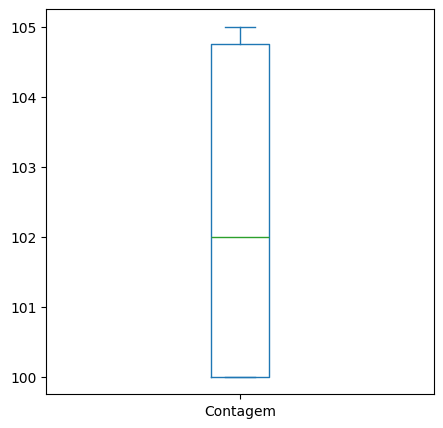

In [67]:
# visualização distribuição dos dados numéricos, mostrando a mediana, os quartis (25% e 75%)
base.plot(kind='box',figsize=(5,5),subplots=True);

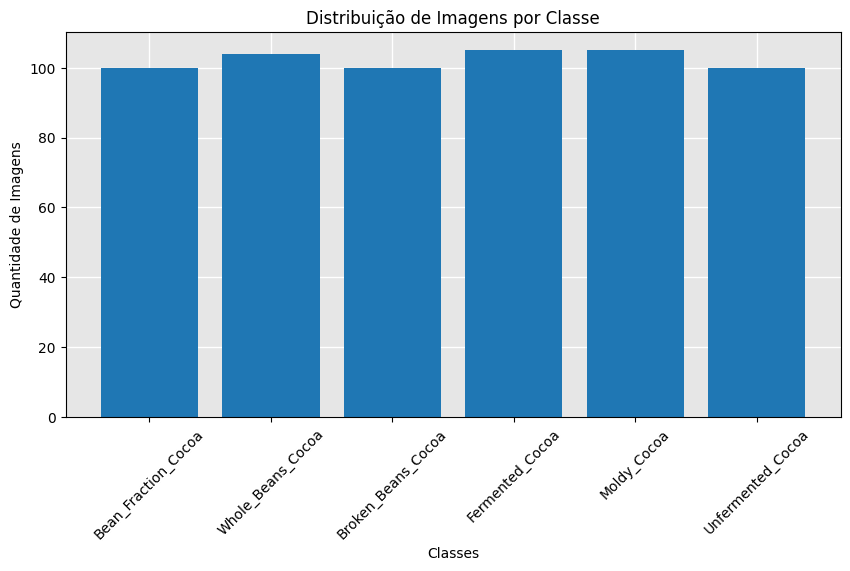

In [68]:
# Import para criação de gráficos e visualizações.
import matplotlib.pyplot as plt
# Gráfico de barras, distribuição das amostras entre as diferentes categorias de grãos de cacau.
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.set_facecolor('#E6E6E6')
plt.grid(True, color='white', linestyle='-', linewidth=1)
ax.set_axisbelow(True)
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Distribuição de Imagens por Classe")
plt.xlabel("Classes")
plt.ylabel("Quantidade de Imagens")
plt.show()

In [69]:
# Lista para armazenar as dimensões (largura, altura) de cada imagem de amostra.
image_sizes = []
# Lista para armazenar o modo de cor (e.g., 'RGB', 'L') de cada imagem de amostra.
image_modes = []

# Iteração sobre cada classe para coletar informações de um subconjunto de imagens.
for classe in classes:
    class_path = os.path.join(DATASET_DIR, classe)
    # Iteração sobre as primeiras 20 imagens de cada classe como amostra para análise.
    for img_name in os.listdir(class_path)[:20]:
        img_path = os.path.join(class_path, img_name)
        # Abre a imagem usando a biblioteca PIL.
        with Image.open(img_path) as img:
            # Adiciona o tamanho da imagem à lista.
            image_sizes.append(img.size)
             # Adiciona o modo de cor da imagem à lista.
            image_modes.append(img.mode)

# Usa Counter para obter a frequência dos tamanhos e modos de cor encontrados.
# Identificar variações e padrões nas imagens do dataset.
Counter(image_sizes), Counter(image_modes)

(Counter({(51, 51): 3,
          (63, 63): 3,
          (46, 46): 2,
          (38, 38): 1,
          (55, 55): 3,
          (60, 60): 1,
          (58, 58): 1,
          (41, 41): 1,
          (52, 52): 1,
          (44, 44): 1,
          (54, 54): 1,
          (66, 66): 1,
          (49, 49): 1,
          (154, 154): 1,
          (109, 109): 4,
          (121, 121): 2,
          (127, 128): 1,
          (122, 122): 2,
          (107, 107): 2,
          (105, 105): 1,
          (120, 120): 3,
          (176, 176): 1,
          (135, 135): 7,
          (136, 136): 1,
          (189, 190): 1,
          (131, 131): 4,
          (186, 186): 1,
          (111, 111): 2,
          (137, 136): 1,
          (151, 151): 1,
          (130, 130): 1,
          (165, 166): 1,
          (85, 85): 1,
          (89, 89): 1,
          (90, 90): 1,
          (93, 93): 3,
          (142, 142): 1,
          (168, 168): 1,
          (79, 79): 1,
          (71, 71): 1,
          (117, 117): 2,
          (98

In [70]:
# Import para contagem eficiente de itens (ex: tamanhos de imagem, modos).
from collections import Counter
# Import para manipulação e análise de dados tabulares (DataFrames).
import pandas as pd

image_size_counts, image_mode_counts = Counter(image_sizes), Counter(image_modes)

# Convertendo a contagem de tamanhos em um DataFrame para melhor visualização.
df_sizes = pd.DataFrame(image_size_counts.items(), columns=['Tamanho da imagem (Largura, Altura)', 'Frequência'])
display(df_sizes.sort_values(by='Frequência', ascending=False).reset_index(drop=True))

# Convertendo a contagem de modos de cor em um DataFrame.
df_modes = pd.DataFrame(image_mode_counts.items(), columns=['Modo de cor', 'Frequência'])
display(df_modes.sort_values(by='Frequência', ascending=False).reset_index(drop=True))

def plot_images_per_class(dataset_dir, classes, samples=5):
    # Cria uma figura para o gráfico e ajusta o tamanho para acomodar a grade de imagens.
    plt.figure(figsize=(15, len(classes)*3))

    # Iteração sobre cada classe para exibir imagens de amostra.
    for idx, classe in enumerate(classes):
        class_path = os.path.join(dataset_dir, classe)
        # Seleciona as primeiras 'samples' imagens de cada classe.
        images = os.listdir(class_path)[:samples]

        # Iteração sobre as imagens selecionadas para a classe atual.
        for i, img_name in enumerate(images):
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path) # Abre a imagem.

            # Cria um subplot na grade: (linhas, colunas, posição atual).
            plt.subplot(len(classes), samples, idx*samples + i + 1)
            # Exibe a imagem.
            plt.imshow(img)
            # Remove os eixos para uma visualização mais limpa.
            plt.axis("off")
            # Adiciona o nome da classe como rótulo na primeira imagem de cada linha.
            if i == 0:
                plt.ylabel(classe, fontsize=12)

    # Ajusta o layout para evitar sobreposição de elementos.
    plt.tight_layout()
    # Exibe o gráfico.
    plt.show()



,"Tamanho da imagem (Largura, Altura)",Frequência
0,"(135, 135)",7
1,"(109, 109)",4
2,"(131, 131)",4
3,"(63, 63)",3
4,"(51, 51)",3
...,...,...
72,"(108, 108)",1
73,"(118, 118)",1
74,"(92, 92)",1
75,"(104, 104)",1


,Modo de cor,Frequência
0,RGB,120


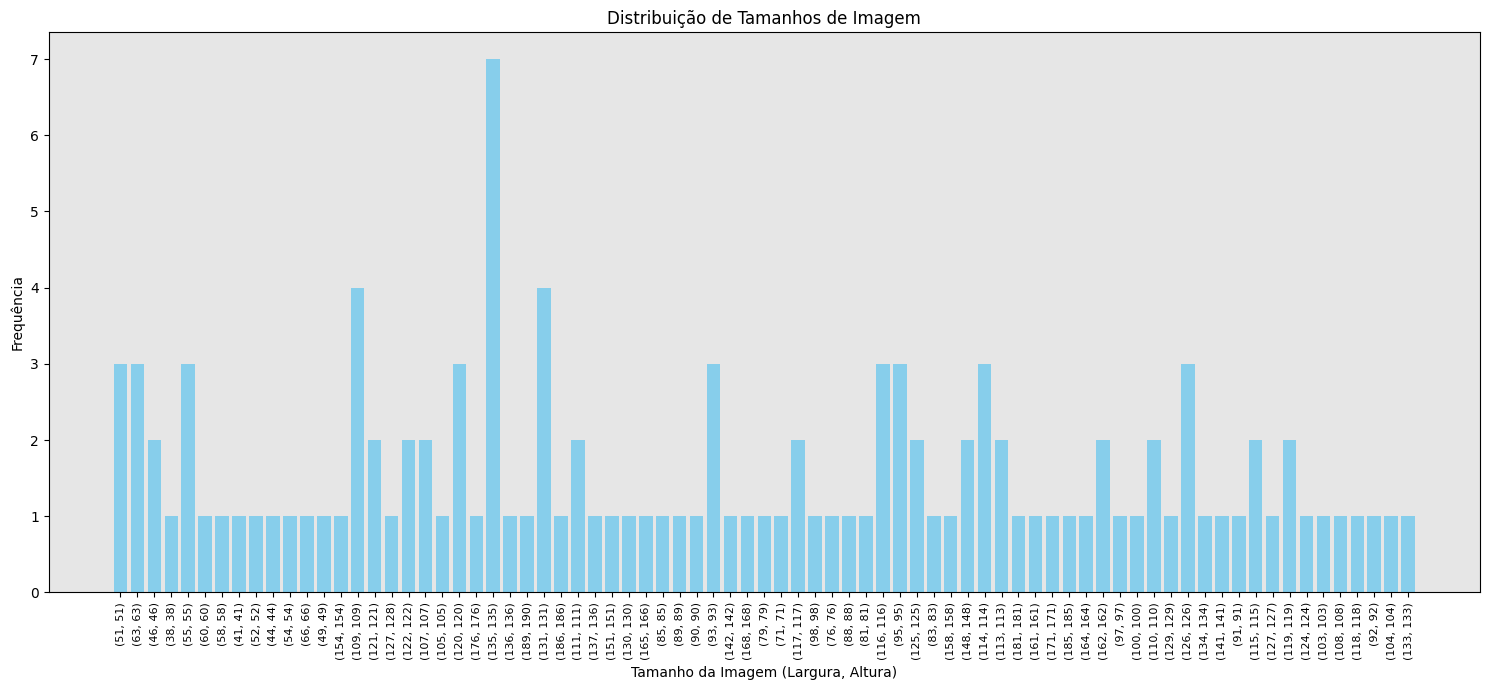

In [71]:
# Import para criação de gráficos e visualizações.
import matplotlib.pyplot as plt

# Gráfico de barras para a distribuição de tamanhos de imagem.
plt.figure(figsize=(15, 7))
ax = plt.gca()
ax.set_facecolor('#E6E6E6')
plt.bar(df_sizes['Tamanho da imagem (Largura, Altura)'].astype(str), df_sizes['Frequência'], color='skyblue')
plt.xlabel('Tamanho da Imagem (Largura, Altura)')
plt.ylabel('Frequência')
plt.title('Distribuição de Tamanhos de Imagem')
plt.xticks(rotation=90, fontsize=8)
# Rotaciona os rótulos do eixo X para melhor legibilidade
plt.tight_layout()
# Ajusta o layout para evitar sobreposição
plt.show()

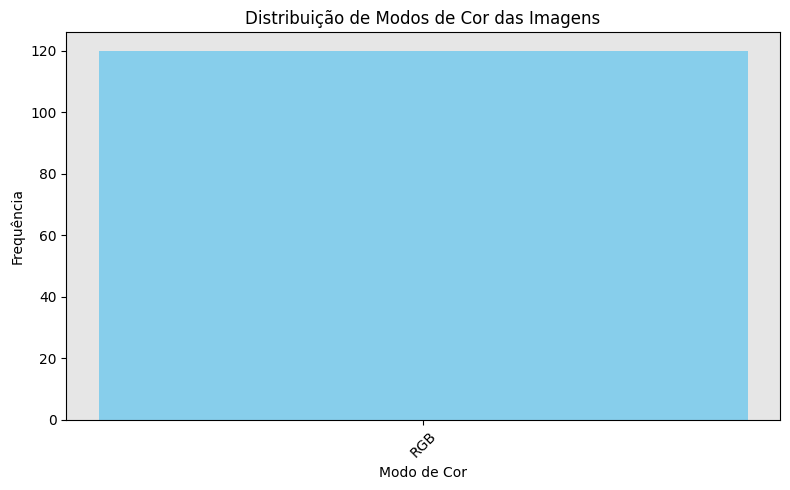

In [72]:
# Gráfico de barras para a distribuição de modos de cor.
plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.set_facecolor('#E6E6E6')
plt.bar(df_modes['Modo de cor'], df_modes['Frequência'], color='skyblue')
plt.xlabel('Modo de Cor')
plt.ylabel('Frequência')
plt.title('Distribuição de Modos de Cor das Imagens')
plt.xticks(rotation=45)
# Rotaciona os rótulos do eixo X, se necessário.
plt.tight_layout()
# Ajusta o layout para evitar sobreposição.
plt.show()

In [73]:
from pathlib import Path

# pegar alguns arquivos de exemplo (um por classe)
amostras = []

base_dir_for_images = Path(DATASET_DIR)
actual_image_classes = sorted([d.name for d in base_dir_for_images.iterdir() if d.is_dir()])

for cls in actual_image_classes:
    cls_dir = base_dir_for_images / cls
    first_image = next(cls_dir.rglob("*.*"), None)
    if first_image:
        amostras.append((cls, first_image))
    else:
        print(f"Nenhuma imagem encontrada em {cls_dir}")

larguras = []
alturas = []
formatos = []

for cls, img_path in amostras:
    with Image.open(img_path) as img:
        w, h = img.size
        larguras.append(w)
        alturas.append(h)
        formatos.append(img.mode)
        print(f"Classe: {cls} | Arquivo: {img_path.name} | Tamanho: {w}x{h} | Modo: {img.mode}")

Classe: Bean_Fraction_Cocoa | Arquivo: BF 01_29.jpg | Tamanho: 51x51 | Modo: RGB
Classe: Broken_Beans_Cocoa | Arquivo: BR01_12.jpg | Tamanho: 165x166 | Modo: RGB
Classe: Fermented_Cocoa | Arquivo: FR01_50.jpg | Tamanho: 158x158 | Modo: RGB
Classe: Moldy_Cocoa | Arquivo: MD01_51.jpg | Tamanho: 135x135 | Modo: RGB
Classe: Unfermented_Cocoa | Arquivo: UF05_83.jpg | Tamanho: 91x91 | Modo: RGB
Classe: Whole_Beans_Cocoa | Arquivo: WB01_89.jpg | Tamanho: 154x154 | Modo: RGB


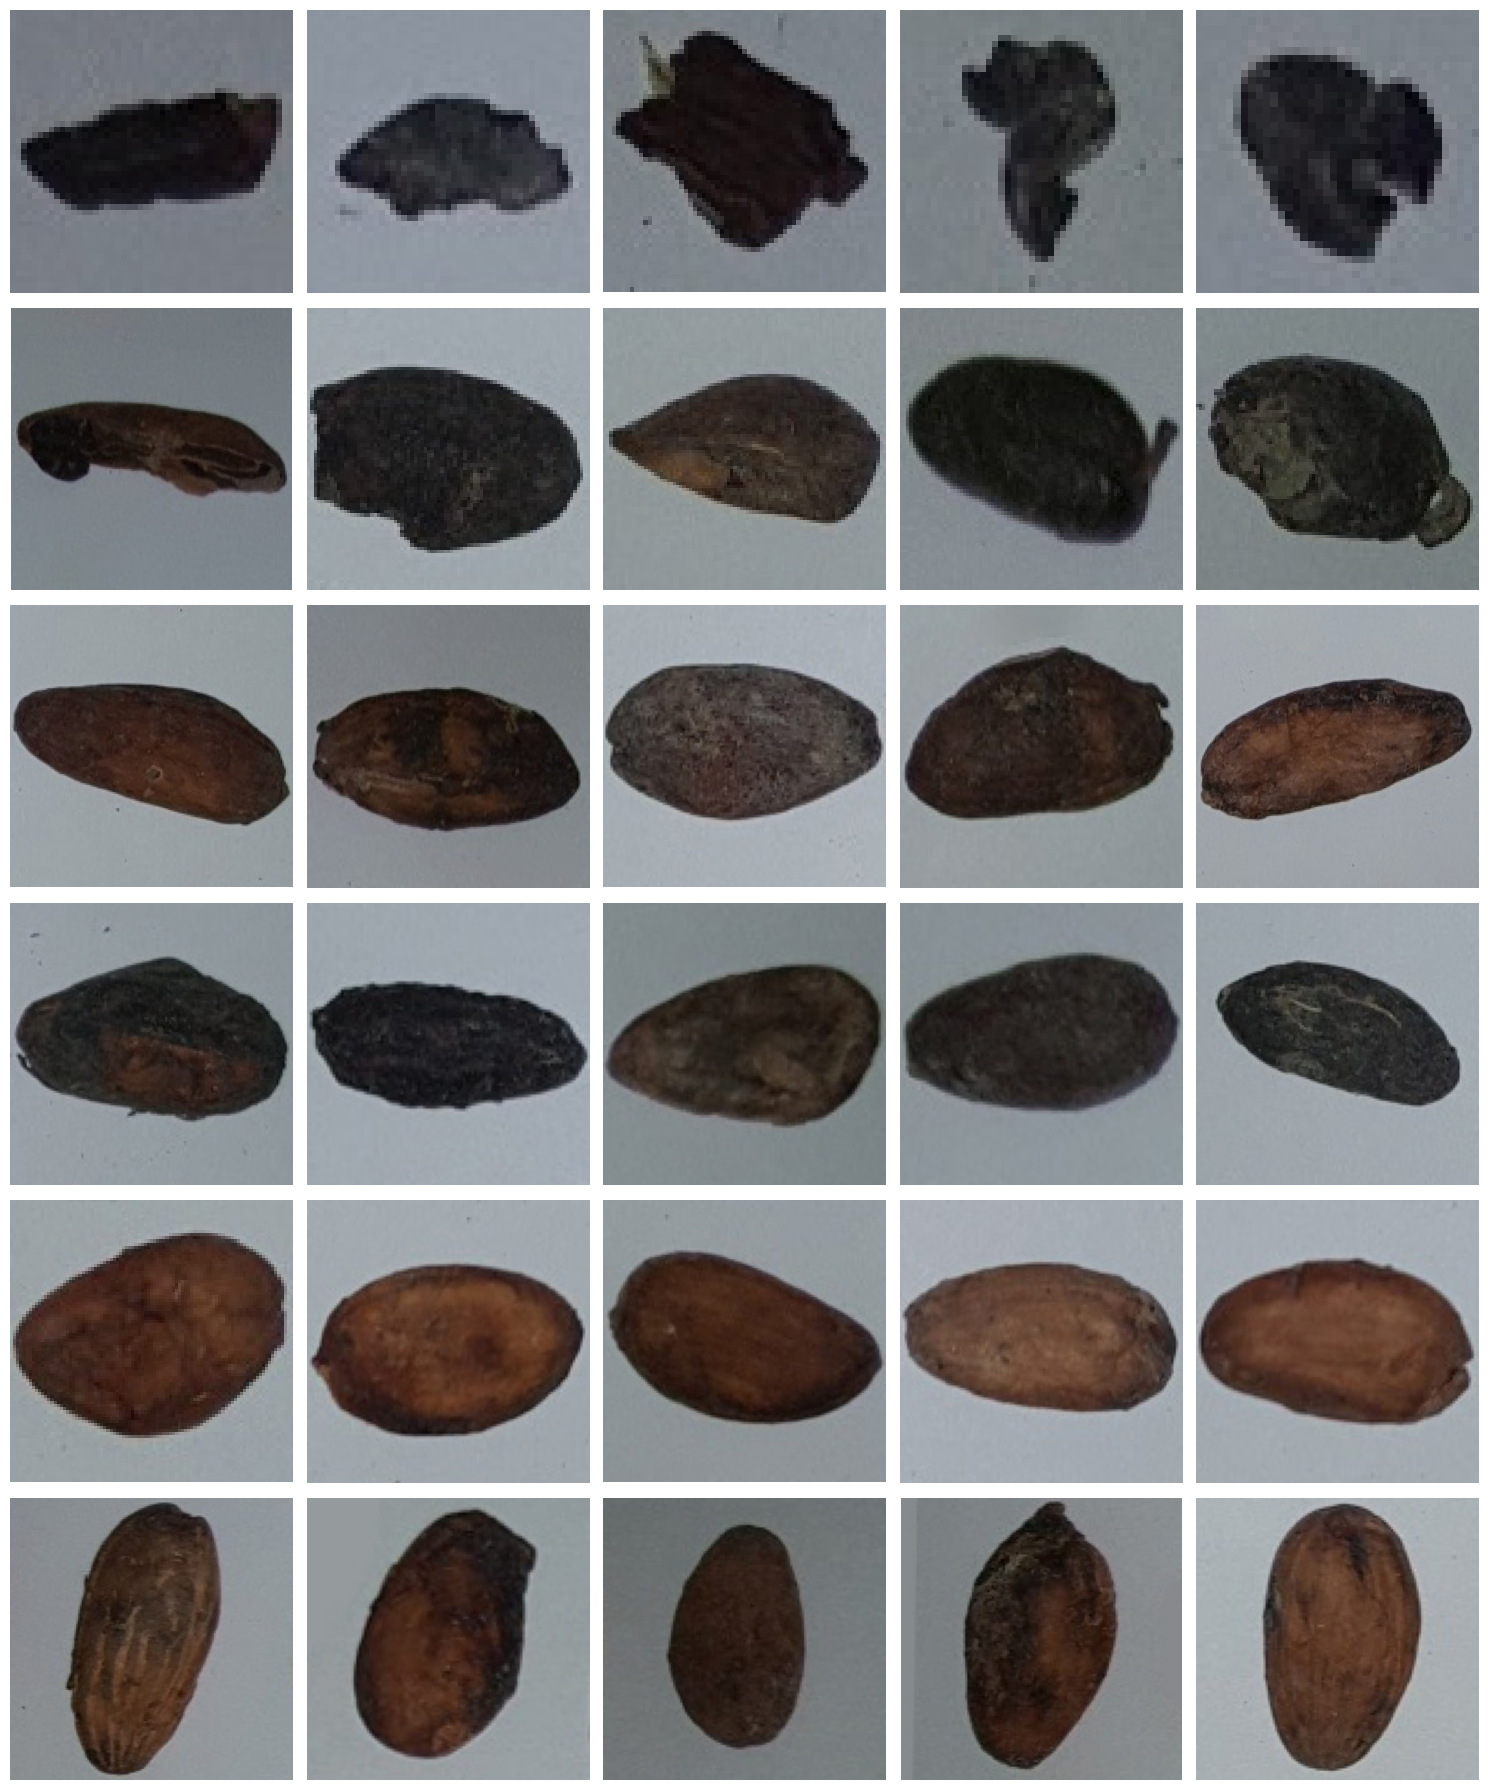

In [74]:
# Gráfico de 5 imagens amostra para cada classe de grão de cacau, dentro de cada categoria.
plot_images_per_class(DATASET_DIR, actual_image_classes, samples=5)

In [75]:
from collections import Counter

# suponha que y seja a lista/array de rótulos das amostras
y = ["boa", "boa", "ruim", "intermediária", "boa", "ruim"]

contagens = Counter(y)
print(contagens)

Counter({'boa': 3, 'ruim': 2, 'intermediária': 1})


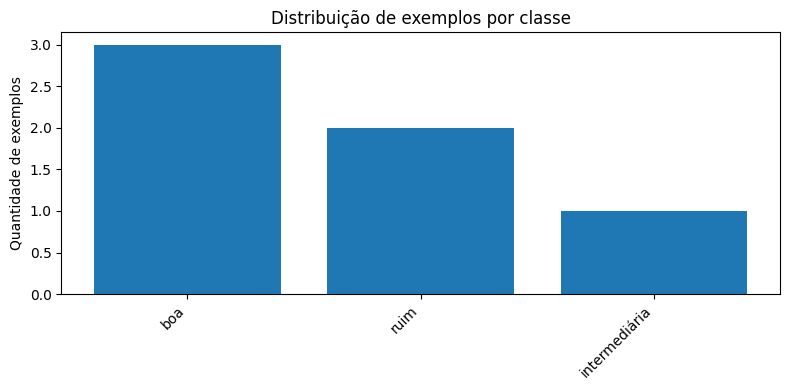

In [76]:
import matplotlib.pyplot as plt

classes = list(contagens.keys())
valores = list(contagens.values())

plt.figure(figsize=(8,4))
plt.bar(classes, valores)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Quantidade de exemplos")
plt.title("Distribuição de exemplos por classe")
plt.tight_layout()
plt.show()

In [77]:
import tensorflow as tf

# Define o tamanho padrão para o redimensionamento das imagens.
# (Largura, Altura)
# Este tamanho é comum para muitos modelos de Deep Learning.
img_size = (224, 224)
# Define o número de imagens a serem processadas em cada etapa de treinamento (batch).
batch_size = 32

# Cria um dataset de imagens usando o utilitário image_dataset_from_directory do Keras.
# Ele carrega as imagens dos subdiretórios dentro de 'base_dir', onde cada subdiretório é uma classe.
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    # Caminho para o diretório raiz das imagens.
    DATASET_DIR,
    # Redimensiona todas as imagens para este tamanho.
    image_size=img_size,
    # Agrupa as imagens em lotes (batches).
    batch_size=batch_size,
    # Embaralha os dados para garantir a aleatoriedade e melhorar o treinamento.
    shuffle=True
)

# Obtém os nomes das classes automaticamente inferidos a partir dos nomes dos subdiretórios.
class_names = train_ds.class_names
print("Classes:", class_names)

Found 614 files belonging to 6 classes.
Classes: ['Bean_Fraction_Cocoa', 'Broken_Beans_Cocoa', 'Fermented_Cocoa', 'Moldy_Cocoa', 'Unfermented_Cocoa', 'Whole_Beans_Cocoa']
